# Boosted Test Trace and Answer Analysis

This notebook analyzes boosted **inference runs only**. It never loads or joins mined trace datasets.

It discovers results under:

- `outputs/inference/test_oracle_boosted`
- `outputs/inference/current_lvar_model_boosted`

The analysis preserves the inference-focused functionality of `test_trace_answer_analysis.ipynb`: accuracy, correct-vs-incorrect behavior, decoding entropy, qualitative errors, domain/topic breakdowns, and table export. It additionally analyzes the boost target, layer mode, alpha sweep, trace attention mass, visual trace attention mass, and THINK attention mass.


In [171]:
%matplotlib inline

import json
import math
from pathlib import Path
import re

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT_CANDIDATES = [
    Path.cwd(),
    Path.cwd().parent,
    Path("/home/csalt/Haider/DVLM/lvar"),
]
ROOT = next(
    (
        candidate.resolve()
        for candidate in ROOT_CANDIDATES
        if (
            (candidate / "outputs/inference/test_oracle_boosted").exists()
            or (candidate / "outputs/inference/current_lvar_model_boosted").exists()
        )
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Could not locate a repository containing boosted inference outputs. "
        "Run this notebook from the repository or configure ROOT_CANDIDATES."
    )

ORACLE_ROOT = ROOT / "outputs/inference/test_oracle_boosted"
FULL_LVAR_ROOT = ROOT / "outputs/inference/current_lvar_model_boosted"

print(f"ROOT: {ROOT}")
print(f"ORACLE_ROOT: {ORACLE_ROOT} (exists={ORACLE_ROOT.exists()})")
print(f"FULL_LVAR_ROOT: {FULL_LVAR_ROOT} (exists={FULL_LVAR_ROOT.exists()})")


ROOT: /home/csalt/Haider/DVLM/lvar
ORACLE_ROOT: /home/csalt/Haider/DVLM/lvar/outputs/inference/test_oracle_boosted (exists=True)
FULL_LVAR_ROOT: /home/csalt/Haider/DVLM/lvar/outputs/inference/current_lvar_model_boosted (exists=True)


## Helpers

These helpers load JSON/JSONL safely, recover boosted-run metadata from both summaries and directory names, and normalize full-pipeline and oracle runs into one schema.


In [172]:
def load_json(path):
    with Path(path).open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_jsonl(path):
    rows = []
    bad_rows = []
    path = Path(path)
    with path.open("r", encoding="utf-8") as handle:
        for line_number, line in enumerate(handle, start=1):
            stripped = line.strip()
            if not stripped:
                continue
            try:
                rows.append(json.loads(stripped))
            except json.JSONDecodeError as exc:
                bad_rows.append({
                    "path": str(path),
                    "line_number": line_number,
                    "error": str(exc),
                    "context": stripped[max(0, exc.pos - 100): exc.pos + 100],
                })
    return rows, bad_rows


def clean_ckpt_name(value):
    if value is None:
        return None
    value = str(value)
    return value.replace("mined_by_", "").replace("evaluated_by_", "").replace("_ckpt", "")


def path_value(parts, prefix):
    value = next((part[len(prefix):] for part in parts if part.startswith(prefix)), None)
    return value


def parse_boosted_path(path):
    parts = Path(path).parts
    alpha_value = path_value(parts, "alpha_")
    return {
        "mined_by": next((clean_ckpt_name(p) for p in parts if p.startswith("mined_by_")), None),
        "evaluated_by": next((clean_ckpt_name(p) for p in parts if p.startswith("evaluated_by_")), None),
        "trace_variant": path_value(parts, "trace_variant_"),
        "boost_target": path_value(parts, "target_"),
        "layer_mode": path_value(parts, "layers_"),
        "alpha": float(alpha_value) if alpha_value is not None else np.nan,
    }


def resolve_artifact(path_value):
    if not path_value:
        return None
    path = Path(path_value)
    if path.is_absolute():
        return path
    return ROOT / path


def pretty_variant(value):
    mapping = {
        "raw": "raw",
        "filtered_cap": "filtered (cap)",
        "filtered_no_cap": "filtered (no cap)",
        "controller_generated": "controller-generated",
    }
    return mapping.get(str(value), str(value))


RUN_KEYS = [
    "run_type", "mined_by", "context", "evaluated_by", "trace_variant",
    "boost_target", "layer_mode", "alpha",
]
MASS_METRICS = [
    "trace_attention_mass",
    "visual_trace_attention_mass",
    "think_attention_mass",
]
ENTROPY_METRICS = [
    "answer_option_entropy",
    "decoded_token_entropy_mean",
    "decoded_token_entropy_median",
    "decoded_token_entropy_max",
]


def make_run_id(record):
    return " | ".join(str(record.get(key)) for key in RUN_KEYS)


def format_alpha(value):
    return "NA" if pd.isna(value) else f"{float(value):.1f}"


## 1. Discover Boosted Inference Runs

Each summary contributes accuracy, output-length statistics, boost configuration, and run-level attention masses. Metadata is read from the summary first and falls back to the directory hierarchy.


In [173]:
summary_rows = []
bad_summary_rows = []

for run_type, inference_root in [
    ("oracle", ORACLE_ROOT),
    ("full_lvar", FULL_LVAR_ROOT),
]:
    if not inference_root.exists():
        continue
    for summary_path in sorted(inference_root.rglob("*_summary.json")):
        try:
            summary = load_json(summary_path)
        except Exception as exc:
            bad_summary_rows.append({"path": str(summary_path), "error": repr(exc)})
            continue
        metrics = summary.get("metrics", {}) or {}
        if not metrics:
            continue
        parsed = parse_boosted_path(summary_path)
        boost = summary.get("trace_boost", {}) or {}
        if not bool(boost.get("enabled", True)):
            continue

        if run_type == "full_lvar":
            mined_by = "full_lvar"
            evaluated_by = "lvar+controller"
            context = "coarse" if summary.get("coarse_context") else "global"
            trace_variant = "controller_generated"
        else:
            mined_by = parsed["mined_by"]
            evaluated_by = parsed["evaluated_by"]
            context = summary.get("context")
            trace_variant = summary.get("trace_variant") or parsed["trace_variant"]

        record = {
            "run_type": run_type,
            "mined_by": mined_by,
            "context": context,
            "evaluated_by": evaluated_by,
            "trace_variant": trace_variant,
            "trace_variant_label": pretty_variant(trace_variant),
            "boost_target": boost.get("target") or parsed["boost_target"],
            "layer_mode": boost.get("layer_mode") or parsed["layer_mode"],
            "alpha": boost.get("alpha", parsed["alpha"]),
            "apply_stage": boost.get("apply_stage"),
            "accuracy": metrics.get("accuracy"),
            "correct": metrics.get("correct"),
            "total": metrics.get("total") or summary.get("num_examples"),
            "avg_trace_actions": metrics.get("avg_trace_actions", metrics.get("avg_controller_actions")),
            "avg_output_tokens": metrics.get("avg_output_tokens"),
            "trace_attention_mass": metrics.get("trace_attention_mass"),
            "visual_trace_attention_mass": metrics.get("visual_trace_attention_mass"),
            "think_attention_mass": metrics.get("think_attention_mass"),
            "output_path": summary.get("output_path"),
            "entropy_tracking_path": summary.get("entropy_tracking_path"),
            "summary_path": str(summary_path.relative_to(ROOT)),
        }
        record["run_id"] = make_run_id(record)
        summary_rows.append(record)

run_summary = pd.DataFrame(summary_rows)
if run_summary.empty:
    raise ValueError(f"No boosted inference summaries found under {ORACLE_ROOT} or {FULL_LVAR_ROOT}")

for column in ["accuracy", "alpha", "avg_trace_actions", "avg_output_tokens", *MASS_METRICS]:
    run_summary[column] = pd.to_numeric(run_summary[column], errors="coerce")
run_summary["accuracy_pct"] = 100 * run_summary["accuracy"]
run_summary = run_summary.sort_values(RUN_KEYS).reset_index(drop=True)

print(f"Runs loaded: {len(run_summary):,}")
print(f"Bad summaries: {len(bad_summary_rows):,}")
display(run_summary.head())
display(run_summary.groupby(["run_type", "boost_target", "layer_mode"]).size().rename("runs").to_frame())


Runs loaded: 72
Bad summaries: 0


,run_type,mined_by,context,evaluated_by,trace_variant,trace_variant_label,boost_target,layer_mode,alpha,apply_stage,accuracy,correct,total,avg_trace_actions,avg_output_tokens,trace_attention_mass,visual_trace_attention_mass,think_attention_mass,output_path,entropy_tracking_path,summary_path,run_id,accuracy_pct
0,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.01,answer_only,0.6398,1483,2318,7.67,6.10,0.062245,0.047726,0.014519,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.01/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.01/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.01,63.98
1,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.10,answer_only,0.0000,0,2318,7.67,30.04,0.086359,0.072511,0.013848,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.1/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.1/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.1,0.00
2,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.20,answer_only,0.0009,2,2318,7.67,30.28,0.115615,0.097073,0.018542,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.2/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.2/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.2,0.09
3,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.30,answer_only,0.0000,0,2318,7.67,30.49,0.146808,0.123119,0.023689,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.3/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.3/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.3,0.00
4,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.40,answer_only,0.0004,1,2318,7.67,30.15,0.181417,0.151812,0.029605,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.4/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.4/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.4,0.04


runs
run_type  boost_target layer_mode       
full_lvar trace_all    all             6
                       latter_half     6
          trace_visual all             6
                       latter_half     6
oracle    trace_all    all            12
                       latter_half    12
          trace_visual all            12
                       latter_half    12

### Sweep Coverage

The intended grid contains both targets, both layer modes, and alpha values 0.1–0.5 for every base inference setting. This table makes missing or duplicate runs visible before comparing results.


In [174]:
EXPECTED_TARGETS = ["trace_all", "trace_visual"]
EXPECTED_LAYER_MODES = ["all", "latter_half"]
EXPECTED_ALPHAS = [0.01,0.1, 0.2, 0.3, 0.4, 0.5]
EXPECTED_COMBINATIONS = {
    (target, layer_mode, alpha)
    for target in EXPECTED_TARGETS
    for layer_mode in EXPECTED_LAYER_MODES
    for alpha in EXPECTED_ALPHAS
}
BASE_SETTING_KEYS = ["run_type", "mined_by", "context", "evaluated_by", "trace_variant"]

coverage_rows = []
for base_key, group in run_summary.groupby(BASE_SETTING_KEYS, dropna=False):
    observed = {
        (row.boost_target, row.layer_mode, round(float(row.alpha), 1))
        for row in group.itertuples()
        if pd.notna(row.alpha)
    }
    missing = sorted(EXPECTED_COMBINATIONS - observed)
    duplicates = int(group.duplicated(["boost_target", "layer_mode", "alpha"]).sum())
    record = dict(zip(BASE_SETTING_KEYS, base_key))
    record.update({
        "observed_settings": len(observed),
        "expected_settings": len(EXPECTED_COMBINATIONS),
        "missing_settings": missing,
        "duplicate_rows": duplicates,
        "complete": not missing and duplicates == 0,
    })
    coverage_rows.append(record)

sweep_coverage = pd.DataFrame(coverage_rows)
display(sweep_coverage)
if not sweep_coverage["complete"].all():
    print("Warning: at least one base inference setting has an incomplete or duplicated boost sweep.")


,run_type,mined_by,context,evaluated_by,trace_variant,observed_settings,expected_settings,missing_settings,duplicate_rows,complete
0,full_lvar,full_lvar,global,lvar+controller,controller_generated,24,24,"[(trace_all, all, 0.01), (trace_all, latter_half, 0.01), (trace_visual, all, 0.01), (trace_visual, latter_half, 0.01)]",0,False
1,oracle,ivtlr,global,ivtlr,raw,24,24,"[(trace_all, all, 0.01), (trace_all, latter_half, 0.01), (trace_visual, all, 0.01), (trace_visual, latter_half, 0.01)]",0,False
2,oracle,lvar,global,lvar,raw,24,24,"[(trace_all, all, 0.01), (trace_all, latter_half, 0.01), (trace_visual, all, 0.01), (trace_visual, latter_half, 0.01)]",0,False


## 2. Accuracy Across Boost Settings

The first table ranks every run. The selector then plots alpha-response curves for one full-pipeline or oracle base setting.


In [175]:
ranked_runs = run_summary[
    [
        *RUN_KEYS, "accuracy_pct", "correct", "total", "avg_trace_actions",
        "avg_output_tokens", *MASS_METRICS, "summary_path",
    ]
].sort_values("accuracy_pct", ascending=False).reset_index(drop=True)

display(
    ranked_runs.style.format({
        "accuracy_pct": "{:.2f}",
        "alpha": "{:.2f}",
        "avg_trace_actions": "{:.2f}",
        "avg_output_tokens": "{:.2f}",
        **{metric: "{:.5f}" for metric in MASS_METRICS},
    }).set_caption("Boosted inference settings ranked by accuracy")
)


,run_type,mined_by,context,evaluated_by,trace_variant,boost_target,layer_mode,alpha,accuracy_pct,correct,total,avg_trace_actions,avg_output_tokens,trace_attention_mass,visual_trace_attention_mass,think_attention_mass,summary_path
0,oracle,lvar,global,lvar,raw,trace_visual,latter_half,0.10,71.01,1646,2318,8.79,6.26,0.05953,0.05441,0.00512,outputs/inference/test_oracle_boosted/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/trace_variant_raw/target_trace_visual/layers_latter_half/alpha_0.1/m3cot_test_predictions_mined-by_lvar_evaluated-by_lvar_global_raw_summary.json
1,oracle,lvar,global,lvar,raw,trace_all,latter_half,0.10,70.75,1640,2318,8.79,6.26,0.06171,0.05314,0.00857,outputs/inference/test_oracle_boosted/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/trace_variant_raw/target_trace_all/layers_latter_half/alpha_0.1/m3cot_test_predictions_mined-by_lvar_evaluated-by_lvar_global_raw_summary.json
2,oracle,lvar,global,lvar,raw,trace_all,latter_half,0.01,70.58,1636,2318,8.79,6.02,0.03674,0.03091,0.00583,outputs/inference/test_oracle_boosted/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/trace_variant_raw/target_trace_all/layers_latter_half/alpha_0.01/m3cot_test_predictions_mined-by_lvar_evaluated-by_lvar_global_raw_summary.json
3,oracle,lvar,global,lvar,raw,trace_visual,latter_half,0.01,70.58,1636,2318,8.79,6.02,0.03653,0.03094,0.00559,outputs/inference/test_oracle_boosted/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/trace_variant_raw/target_trace_visual/layers_latter_half/alpha_0.01/m3cot_test_predictions_mined-by_lvar_evaluated-by_lvar_global_raw_summary.json
4,oracle,ivtlr,global,ivtlr,raw,trace_visual,latter_half,0.10,70.36,1631,2318,8.60,6.11,0.05348,0.04670,0.00678,outputs/inference/test_oracle_boosted/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_raw/target_trace_visual/layers_latter_half/alpha_0.1/m3cot_test_predictions_mined-by_ivtlr_evaluated-by_ivtlr_global_raw_summary.json
5,oracle,ivtlr,global,ivtlr,raw,trace_all,latter_half,0.10,70.36,1631,2318,8.60,6.13,0.05582,0.04521,0.01061,outputs/inference/test_oracle_boosted/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_raw/target_trace_all/layers_latter_half/alpha_0.1/m3cot_test_predictions_mined-by_ivtlr_evaluated-by_ivtlr_global_raw_summary.json
6,oracle,ivtlr,global,ivtlr,raw,trace_all,latter_half,0.01,70.23,1628,2318,8.60,6.00,0.03222,0.02462,0.00760,outputs/inference/test_oracle_boosted/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_raw/target_trace_all/layers_latter_half/alpha_0.01/m3cot_test_predictions_mined-by_ivtlr_evaluated-by_ivtlr_global_raw_summary.json
7,oracle,ivtlr,global,ivtlr,raw,trace_visual,latter_half,0.01,70.23,1628,2318,8.60,6.00,0.03199,0.02469,0.00730,outputs/inference/test_oracle_boosted/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_raw/target_trace_visual/layers_latter_half/alpha_0.01/m3cot_test_predictions_mined-by_ivtlr_evaluated-by_ivtlr_global_raw_summary.json
8,oracle,lvar,global,lvar,raw,trace_visual,all,0.01,70.19,1627,2318,8.79,6.14,0.05221,0.04216,0.01005,outputs/inference/test_oracle_boosted/mined_by_lvar_ckpt/evaluated_by_lvar_ckpt/trace_variant_raw/target_trace_visual/layers_all/alpha_0.01/m3cot_test_predictions_mined-by_lvar_evaluated-by_lvar_global_raw_summary.json
9,oracle,ivtlr,global,ivtlr,raw,trace_visual,all,0.01,70.10,1625,2318,8.60,6.03,0.04982,0.03745,0.01237,outputs/inference/test_oracle_boosted/mined_by_ivtlr_ckpt/evaluated_by_ivtlr_ckpt/trace_variant_raw/target_trace_visual/layers_all/alpha_0.01/m3cot_test_predictions_mined-by_ivtlr_evaluated-by_ivtlr_global_raw_summary.json


In [176]:
# Change these selectors to inspect a different base inference setting.
SELECT_RUN_TYPE = "full_lvar"
SELECT_MINED_BY = "full_lvar"
SELECT_CONTEXT = "global"
SELECT_EVALUATED_BY = "lvar+controller"
SELECT_TRACE_VARIANT = "controller_generated"

selected_summary = run_summary[
    (run_summary["run_type"] == SELECT_RUN_TYPE)
    & (run_summary["mined_by"] == SELECT_MINED_BY)
    & (run_summary["context"] == SELECT_CONTEXT)
    & (run_summary["evaluated_by"] == SELECT_EVALUATED_BY)
    & (run_summary["trace_variant"] == SELECT_TRACE_VARIANT)
].copy()

if selected_summary.empty:
    print("The default selection is unavailable; using the first discovered base setting.")
    first = run_summary.iloc[0]
    selected_summary = run_summary[
        (run_summary["run_type"] == first["run_type"])
        & (run_summary["mined_by"] == first["mined_by"])
        & (run_summary["context"] == first["context"])
        & (run_summary["evaluated_by"] == first["evaluated_by"])
        & (run_summary["trace_variant"] == first["trace_variant"])
    ].copy()

SELECTED_BASE = selected_summary.iloc[0][BASE_SETTING_KEYS].to_dict()
print("Selected base setting:", SELECTED_BASE)
display(selected_summary.sort_values(["boost_target", "layer_mode", "alpha"]))


Selected base setting: {'run_type': 'full_lvar', 'mined_by': 'full_lvar', 'context': 'global', 'evaluated_by': 'lvar+controller', 'trace_variant': 'controller_generated'}


,run_type,mined_by,context,evaluated_by,trace_variant,trace_variant_label,boost_target,layer_mode,alpha,apply_stage,accuracy,correct,total,avg_trace_actions,avg_output_tokens,trace_attention_mass,visual_trace_attention_mass,think_attention_mass,output_path,entropy_tracking_path,summary_path,run_id,accuracy_pct
0,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.01,answer_only,0.6398,1483,2318,7.67,6.10,0.062245,0.047726,0.014519,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.01/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.01/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.01,63.98
1,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.10,answer_only,0.0000,0,2318,7.67,30.04,0.086359,0.072511,0.013848,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.1/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.1/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.1,0.00
2,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.20,answer_only,0.0009,2,2318,7.67,30.28,0.115615,0.097073,0.018542,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.2/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.2/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.2,0.09
3,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.30,answer_only,0.0000,0,2318,7.67,30.49,0.146808,0.123119,0.023689,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.3/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.3/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.3,0.00
4,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.40,answer_only,0.0004,1,2318,7.67,30.15,0.181417,0.151812,0.029605,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.4/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.4/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.4,0.04
5,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,all,0.50,answer_only,0.0004,1,2318,7.67,30.02,0.216602,0.181833,0.034769,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.5/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.5/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.5,0.04
6,full_lvar,full_lvar,global,lvar+controller,controller_generated,controller-generated,trace_all,latter_half,0.01,answer_only,0.6588,1527,2318,7.67,6.00,0.032705,0.025514,0.007191,None,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_latter_half/alpha_0.01/m3cot_lvar_predictions_entropy_tracking.json,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_latter_half/alpha_0.01/m3cot_lvar_predictions_summary.json,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | latter_h

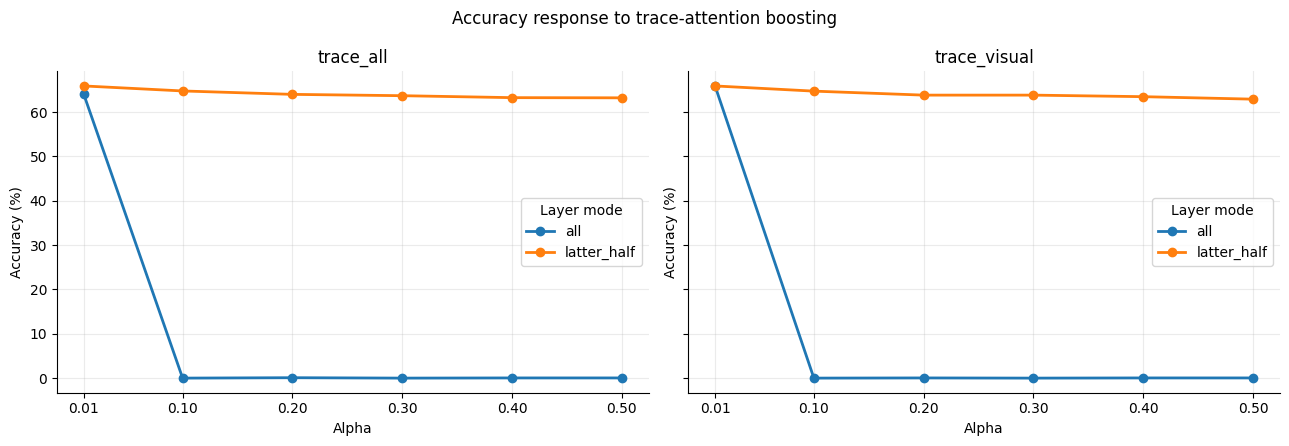

In [177]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, target in zip(axes, EXPECTED_TARGETS):
    target_frame = selected_summary[selected_summary["boost_target"] == target]
    for layer_mode, group in target_frame.groupby("layer_mode"):
        group = group.sort_values("alpha")
        ax.plot(group["alpha"], group["accuracy_pct"], marker="o", linewidth=2, label=layer_mode)
    ax.set_title(target)
    ax.set_xlabel("Alpha")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(EXPECTED_ALPHAS)
    ax.legend(title="Layer mode")
plt.suptitle("Accuracy response to trace-attention boosting")
plt.tight_layout()
plt.show()


In [178]:
accuracy_ablation = (
    run_summary
    .pivot_table(
        index=BASE_SETTING_KEYS + ["alpha"],
        columns=["boost_target", "layer_mode"],
        values="accuracy_pct",
        aggfunc="first",
    )
    .sort_index()
)
display(accuracy_ablation.style.format("{:.2f}").set_caption("Accuracy (%) across target × layer-mode ablations"))

best_per_base = (
    run_summary.sort_values("accuracy_pct", ascending=False)
    .groupby(BASE_SETTING_KEYS, dropna=False)
    .head(1)
    [[*BASE_SETTING_KEYS, "boost_target", "layer_mode", "alpha", "accuracy_pct", *MASS_METRICS]]
    .reset_index(drop=True)
)
display(best_per_base.style.format({"alpha": "{:.1f}", "accuracy_pct": "{:.2f}", **{m: "{:.5f}" for m in MASS_METRICS}}))


,run_type,mined_by,context,evaluated_by,trace_variant,boost_target,layer_mode,alpha,accuracy_pct,trace_attention_mass,visual_trace_attention_mass,think_attention_mass
0,oracle,lvar,global,lvar,raw,trace_visual,latter_half,0.1,71.01,0.05953,0.05441,0.00512
1,oracle,ivtlr,global,ivtlr,raw,trace_visual,latter_half,0.1,70.36,0.05348,0.04670,0.00678
2,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_visual,latter_half,0.0,65.88,0.03245,0.02557,0.00688


## 3. Load Prediction Rows

Prediction JSONLs are loaded through their summaries, so only completed inference runs enter the sample-level analyses. No trace dataset is read.


In [179]:
prediction_rows = []
bad_prediction_rows = []
missing_prediction_files = []

for summary in run_summary.itertuples(index=False):
    output_path = resolve_artifact(summary.output_path)
    if output_path is None:
        summary_path = ROOT / summary.summary_path
        candidates = list(summary_path.parent.glob("*.jsonl"))
        candidates = [path for path in candidates if "entropy_tracking" not in path.name]
        output_path = candidates[0] if len(candidates) == 1 else None
    if output_path is None or not output_path.exists():
        missing_prediction_files.append(str(output_path))
        continue

    rows, bad_rows = load_jsonl(output_path)
    bad_prediction_rows.extend(bad_rows)
    metadata = {key: getattr(summary, key) for key in RUN_KEYS}
    metadata["run_id"] = summary.run_id
    for row in rows:
        prediction_rows.append({
            **metadata,
            "example_id": row.get("example_id"),
            "question": row.get("question"),
            "correct": bool(row.get("correct")),
            "gold_answer": row.get("gold_answer"),
            "raw_answer": row.get("raw_answer"),
            "generated_text": row.get("generated_text"),
            "decoded_answer": row.get("decoded_answer"),
            "domain": row.get("domain"),
            "topic": row.get("topic"),
            "num_inference_trace_actions": (
                row.get("num_trace_actions")
                if row.get("num_trace_actions") is not None
                else row.get("num_steps")
            ),
            "num_output_tokens": row.get("num_output_tokens"),
            "trace_attention_mass": row.get("trace_attention_mass"),
            "visual_trace_attention_mass": row.get("visual_trace_attention_mass"),
            "think_attention_mass": row.get("think_attention_mass"),
            "prediction_path": str(output_path.relative_to(ROOT)) if output_path.is_relative_to(ROOT) else str(output_path),
        })

predictions = pd.DataFrame(prediction_rows)
if predictions.empty:
    raise ValueError("No boosted prediction JSONLs could be loaded.")

for column in ["alpha", "num_inference_trace_actions", "num_output_tokens", *MASS_METRICS]:
    predictions[column] = pd.to_numeric(predictions[column], errors="coerce")

print(f"Prediction rows: {len(predictions):,}")
print(f"Unique runs: {predictions['run_id'].nunique():,}")
print(f"Bad JSONL rows: {len(bad_prediction_rows):,}")
print(f"Missing prediction files: {len(missing_prediction_files):,}")
display(predictions.head())


Prediction rows: 166,896
Unique runs: 72
Bad JSONL rows: 0
Missing prediction files: 0


,run_type,mined_by,context,evaluated_by,trace_variant,boost_target,layer_mode,alpha,run_id,example_id,question,correct,gold_answer,raw_answer,generated_text,decoded_answer,domain,topic,num_inference_trace_actions,num_output_tokens,trace_attention_mass,visual_trace_attention_mass,think_attention_mass,prediction_path
0,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.01,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.01,physical-commonsense-1398,[Question]:{What is the likely purpose of the troll statue under the bridge?}\n[Options]:\n(A).{To scare away trespassers}\n(B).{To bring attention to the c...,False,b,B,"Therefore, the answer is C",None,commonsense,physical-commonsense,4,6,0.052597,0.019837,0.032760,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.01/m3cot_lvar_predictions.jsonl
1,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.01,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.01,physical-commonsense-1342,[Question]:{What is the primary business of the truck?}\n[Options]:\n(A).{Transporting clothing}\n(B).{Selling food}\n(C).{Selling books}\n(D).{Transporting...,True,b,B,"Therefore, the answer is B",None,commonsense,physical-commonsense,8,6,0.073387,0.035569,0.037818,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.01/m3cot_lvar_predictions.jsonl
2,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.01,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.01,physical-commonsense-1423,[Question]:{What kind of snowboarders is the mountain in the picture suitable for?}\n[Options]:\n(A).{Beginner only}\n(B).{Not sure}\n(C).{Advanced only}\n(...,True,c,C,"Therefore, the answer is C",None,commonsense,physical-commonsense,6,6,0.050908,0.021298,0.029610,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.01/m3cot_lvar_predictions.jsonl
3,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.01,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.01,physical-commonsense-1364,[Question]:{What is the purpose of the red train cart?}\n[Options]:\n(A).{Transporting cargo}\n(B).{Providing living quarters}\n(C).{Carrying passengers}\n(...,False,b,B,"Therefore, the answer is C",None,commonsense,physical-commonsense,5,6,0.065411,0.035530,0.029880,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.01/m3cot_lvar_predictions.jsonl
4,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.01,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.01,physical-commonsense-1350,[Question]:{What is the possible purpose of the building in the background?}\n[Options]:\n(A).{A shopping mall}\n(B).{A bird museum}\n(C).{An office buildin...,False,c,C,"Therefore, the answer is D",None,commonsense,physical-commonsense,8,6,0.061699,0.031412,0.030287,outputs/inference/current_lvar_model_boosted/target_trace_all/layers_all/alpha_0.01/m3cot_lvar_predictions.jsonl


## 4. Correct vs Incorrect Outcomes

This is the inference-only counterpart of the original correctness analysis. It compares output length, controller/replayed action count, and all three tracked attention masses.


In [180]:
correctness_summary = (
    predictions
    .groupby(RUN_KEYS + ["correct"], dropna=False)
    .agg(
        examples=("example_id", "nunique"),
        mean_trace_actions=("num_inference_trace_actions", "mean"),
        mean_output_tokens=("num_output_tokens", "mean"),
        mean_trace_attention_mass=("trace_attention_mass", "mean"),
        median_trace_attention_mass=("trace_attention_mass", "median"),
        mean_visual_trace_attention_mass=("visual_trace_attention_mass", "mean"),
        mean_think_attention_mass=("think_attention_mass", "mean"),
    )
    .reset_index()
    .sort_values(RUN_KEYS + ["correct"])
)
display(
    correctness_summary.style.format({
        "alpha": "{:.1f}",
        "mean_trace_actions": "{:.2f}",
        "mean_output_tokens": "{:.2f}",
        "mean_trace_attention_mass": "{:.5f}",
        "median_trace_attention_mass": "{:.5f}",
        "mean_visual_trace_attention_mass": "{:.5f}",
        "mean_think_attention_mass": "{:.5f}",
    }).set_caption("Prediction behavior split by correct vs incorrect outcomes")
)


,run_type,mined_by,context,evaluated_by,trace_variant,boost_target,layer_mode,alpha,correct,examples,mean_trace_actions,mean_output_tokens,mean_trace_attention_mass,median_trace_attention_mass,mean_visual_trace_attention_mass,mean_think_attention_mass
0,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.0,False,835,7.65,6.05,0.06507,0.06258,0.04789,0.01718
1,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.0,True,1483,7.67,6.13,0.06065,0.05940,0.04763,0.01302
2,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.1,False,2318,7.67,30.04,0.08636,0.08413,0.07251,0.01385
3,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.2,False,2316,7.67,30.28,0.11562,0.11337,0.09707,0.01855
4,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.2,True,2,7.00,29.50,0.11023,0.11023,0.09663,0.01361
5,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.3,False,2318,7.67,30.49,0.14681,0.14465,0.12312,0.02369
6,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.4,False,2317,7.67,30.17,0.18139,0.17894,0.15177,0.02962
7,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.4,True,1,8.00,2.00,0.25529,0.25529,0.25529,0.00000
8,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.5,False,2317,7.67,30.03,0.21657,0.21374,0.18179,0.03478
9,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.5,True,1,8.00,2.00,0.28926,0.28926,0.28926,0.00000


Selected run: full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_visual | all | 0.01
Rows: 2,318


,examples
correct,
True,1527
False,791


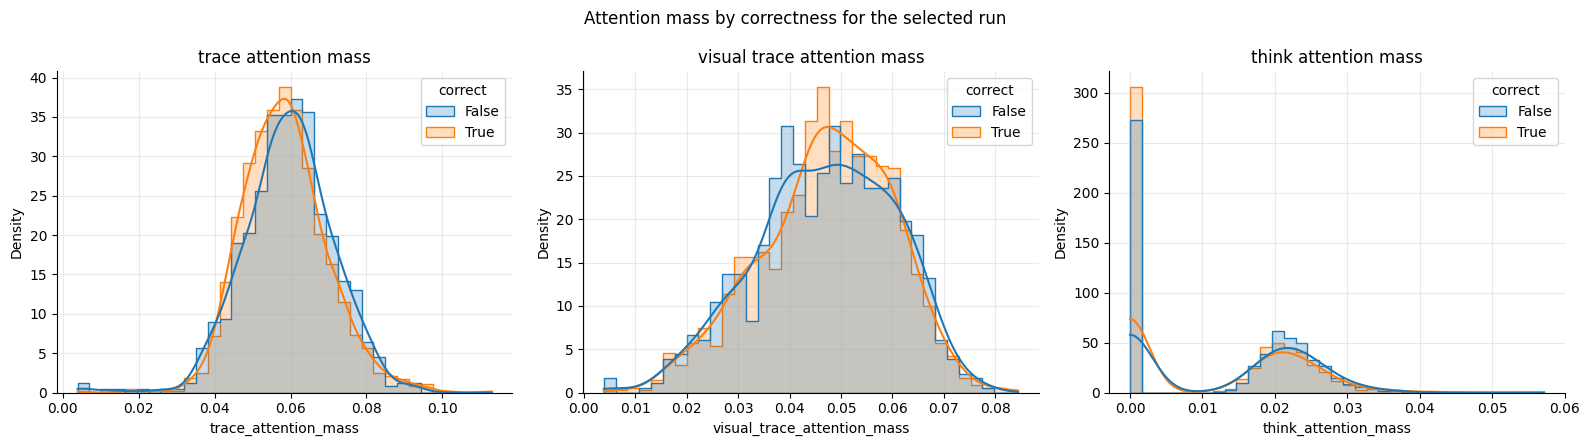

In [181]:
SELECTED_RUN_ID = selected_summary.sort_values("accuracy_pct", ascending=False).iloc[0]["run_id"]
selected_predictions = predictions[predictions["run_id"] == SELECTED_RUN_ID].copy()

print(f"Selected run: {SELECTED_RUN_ID}")
print(f"Rows: {len(selected_predictions):,}")
display(selected_predictions["correct"].value_counts(dropna=False).rename("examples").to_frame())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, MASS_METRICS):
    usable = selected_predictions.dropna(subset=[metric])
    if HAS_SEABORN:
        sns.histplot(
            data=usable, x=metric, hue="correct", bins=35, kde=True,
            stat="density", common_norm=False, element="step", ax=ax,
        )
    else:
        for correct, group in usable.groupby("correct"):
            ax.hist(group[metric], bins=35, alpha=0.45, density=True, label=f"correct={correct}")
        ax.legend()
    ax.set_title(metric.replace("_", " "))
plt.suptitle("Attention mass by correctness for the selected run")
plt.tight_layout()
plt.show()


## 5. Boosting-Specific Attention Analysis

These plots answer the central intervention questions:

1. Does increasing alpha increase attention mass on the intended trace positions?
2. Does trace_all increase THINK attention more strongly than trace_visual?
3. Does higher trace attention coincide with higher accuracy?


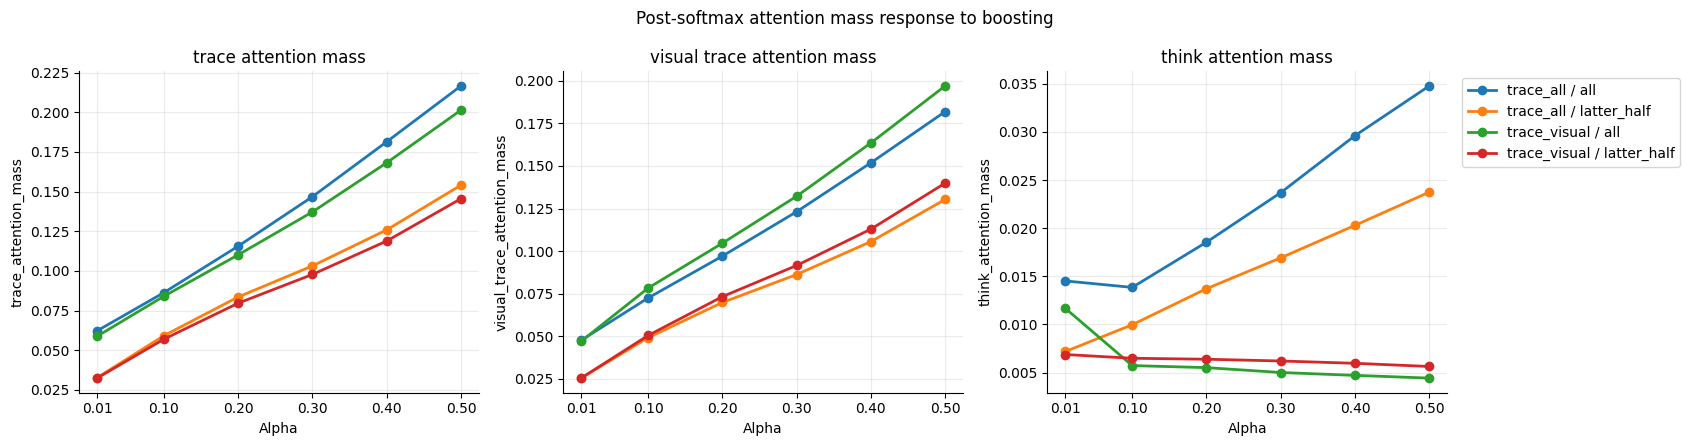

In [182]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, metric in zip(axes, MASS_METRICS):
    for (target, layer_mode), group in selected_summary.groupby(["boost_target", "layer_mode"]):
        group = group.sort_values("alpha")
        ax.plot(
            group["alpha"], group[metric], marker="o", linewidth=2,
            label=f"{target} / {layer_mode}",
        )
    ax.set_xlabel("Alpha")
    ax.set_ylabel(metric)
    ax.set_xticks(EXPECTED_ALPHAS)
    ax.set_title(metric.replace("_", " "))
axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Post-softmax attention mass response to boosting")
plt.tight_layout()
plt.show()


In [183]:
response_rows = []
for group_key, group in run_summary.groupby(BASE_SETTING_KEYS + ["boost_target", "layer_mode"], dropna=False):
    record = dict(zip(BASE_SETTING_KEYS + ["boost_target", "layer_mode"], group_key))
    record["runs"] = len(group)
    for metric in [*MASS_METRICS, "accuracy_pct"]:
        usable = group[["alpha", metric]].dropna()
        record[f"{metric}_spearman_alpha"] = (
            usable["alpha"].corr(usable[metric], method="spearman")
            if len(usable) >= 2 and usable["alpha"].nunique() >= 2
            else np.nan
        )
        record[f"{metric}_linear_slope"] = (
            float(np.polyfit(usable["alpha"], usable[metric], 1)[0])
            if len(usable) >= 2 and usable["alpha"].nunique() >= 2
            else np.nan
        )
    response_rows.append(record)

alpha_response = pd.DataFrame(response_rows)
display(
    alpha_response.style.format({
        column: "{:.5f}"
        for column in alpha_response.columns
        if column.endswith("_slope") or column.endswith("_alpha")
    }).set_caption("Within-setting response of attention and accuracy to alpha")
)


,run_type,mined_by,context,evaluated_by,trace_variant,boost_target,layer_mode,runs,trace_attention_mass_spearman_alpha,trace_attention_mass_linear_slope,visual_trace_attention_mass_spearman_alpha,visual_trace_attention_mass_linear_slope,think_attention_mass_spearman_alpha,think_attention_mass_linear_slope,accuracy_pct_spearman_alpha,accuracy_pct_linear_slope
0,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,6,1.00000,0.31562,1.00000,0.27091,0.94286,0.04471,-0.29424,-90.84145
1,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,latter_half,6,1.00000,0.23937,1.00000,0.20547,1.00000,0.03389,-1.00000,-5.25576
2,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_visual,all,6,1.00000,0.28763,1.00000,0.29899,-1.00000,-0.01136,-0.15430,-93.52592
3,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_visual,latter_half,6,1.00000,0.22277,1.00000,0.22508,-1.00000,-0.00231,-0.98561,-5.37766
4,oracle,ivtlr,global,ivtlr,raw,trace_all,all,6,1.00000,0.31649,1.00000,0.26743,1.00000,0.04906,-0.84515,-96.27134
5,oracle,ivtlr,global,ivtlr,raw,trace_all,latter_half,6,1.00000,0.22622,1.00000,0.19019,1.00000,0.03603,-0.94286,-5.46173
6,oracle,ivtlr,global,ivtlr,raw,trace_visual,all,6,1.00000,0.28712,1.00000,0.29971,-1.00000,-0.01259,-0.65465,-97.51445
7,oracle,ivtlr,global,ivtlr,raw,trace_visual,latter_half,6,1.00000,0.20875,1.00000,0.21181,-1.00000,-0.00306,-0.94286,-5.51210
8,oracle,lvar,global,lvar,raw,trace_all,all,6,1.00000,0.34656,1.00000,0.28081,1.00000,0.06575,-0.57682,-90.20059
9,oracle,lvar,global,lvar,raw,trace_all,latter_half,6,1.00000,0.24568,1.00000,0.21061,1.00000,0.03507,-0.94286,-10.71318


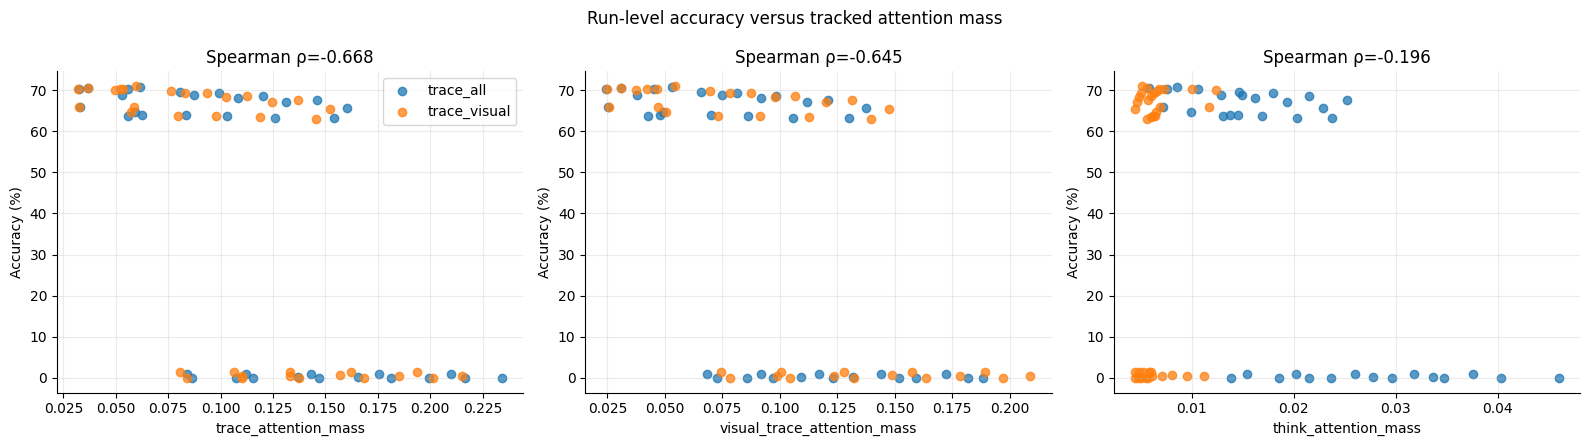

In [184]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, MASS_METRICS):
    usable = run_summary.dropna(subset=[metric, "accuracy_pct"])
    for target, group in usable.groupby("boost_target"):
        ax.scatter(group[metric], group["accuracy_pct"], alpha=0.75, label=target)
    correlation = usable[[metric, "accuracy_pct"]].corr(method="spearman").iloc[0, 1] if len(usable) >= 2 else np.nan
    ax.set_xlabel(metric)
    ax.set_ylabel("Accuracy (%)")
    ax.set_title(f"Spearman ρ={correlation:.3f}")
axes[0].legend()
plt.suptitle("Run-level accuracy versus tracked attention mass")
plt.tight_layout()
plt.show()


In [185]:
target_comparison = (
    run_summary
    .pivot_table(
        index=BASE_SETTING_KEYS + ["layer_mode", "alpha"],
        columns="boost_target",
        values=["accuracy_pct", *MASS_METRICS],
        aggfunc="first",
    )
    .sort_index()
)
display(target_comparison.style.format("{:.5f}").set_caption("Paired trace_all versus trace_visual comparison"))


## 6. Decoding Entropy Analysis

Entropy sidecars retain the original notebook's answer-option and decoded-token uncertainty analyses. The attention-mass fields are also loaded so uncertainty can be compared directly with grounding behavior.


In [186]:
entropy_rows = []
missing_entropy_files = []

for summary in run_summary.itertuples(index=False):
    entropy_path = resolve_artifact(summary.entropy_tracking_path)
    if entropy_path is None and summary.output_path:
        prediction_path = resolve_artifact(summary.output_path)
        entropy_path = prediction_path.with_name(f"{prediction_path.stem}_entropy_tracking.json")
    if entropy_path is None or not entropy_path.exists():
        missing_entropy_files.append(str(entropy_path))
        continue

    rows = load_json(entropy_path)
    metadata = {key: getattr(summary, key) for key in RUN_KEYS}
    metadata["run_id"] = summary.run_id
    for row in rows:
        entropy_rows.append({
            **metadata,
            "example_id": row.get("example_id"),
            "correct": bool(row.get("correct")),
            "gold_answer": row.get("gold_answer"),
            "decoded_answer": row.get("decoded_answer"),
            "num_output_tokens": row.get("num_output_tokens"),
            "answer_option_entropy": row.get("answer_option_entropy"),
            "decoded_token_entropy_mean": row.get("decoded_token_entropy_mean"),
            "decoded_token_entropy_median": row.get("decoded_token_entropy_median"),
            "decoded_token_entropy_max": row.get("decoded_token_entropy_max"),
            "answer_option_selected_option": row.get("answer_option_selected_option"),
            "answer_option_decoded_token_index": row.get("answer_option_decoded_token_index"),
            "answer_option_probabilities": row.get("answer_option_probabilities"),
            "decoded_token_entropies": row.get("decoded_token_entropies"),
            "trace_attention_mass": row.get("trace_attention_mass"),
            "visual_trace_attention_mass": row.get("visual_trace_attention_mass"),
            "think_attention_mass": row.get("think_attention_mass"),
            "entropy_path": str(entropy_path.relative_to(ROOT)) if entropy_path.is_relative_to(ROOT) else str(entropy_path),
        })

entropy_df = pd.DataFrame(entropy_rows)
for column in [*ENTROPY_METRICS, *MASS_METRICS, "alpha", "num_output_tokens"]:
    entropy_df[column] = pd.to_numeric(entropy_df[column], errors="coerce")

print(f"Entropy rows: {len(entropy_df):,}")
print(f"Runs with entropy: {entropy_df['run_id'].nunique():,}")
print(f"Missing entropy sidecars: {len(missing_entropy_files):,}")
coverage = entropy_df[[*ENTROPY_METRICS, *MASS_METRICS]].notna().mean().rename("fraction_present").to_frame()
display(coverage.style.format("{:.2%}"))


Entropy rows: 166,896
Runs with entropy: 72
Missing entropy sidecars: 0


,fraction_present
answer_option_entropy,69.74%
decoded_token_entropy_mean,99.60%
decoded_token_entropy_median,99.60%
decoded_token_entropy_max,99.60%
trace_attention_mass,100.00%
visual_trace_attention_mass,100.00%
think_attention_mass,100.00%


In [187]:
entropy_summary = (
    entropy_df
    .groupby(RUN_KEYS + ["correct"], dropna=False)
    .agg(
        samples=("example_id", "size"),
        option_entropy_available=("answer_option_entropy", "count"),
        mean_option_entropy=("answer_option_entropy", "mean"),
        median_option_entropy=("answer_option_entropy", "median"),
        mean_answer_entropy=("decoded_token_entropy_mean", "mean"),
        median_answer_entropy=("decoded_token_entropy_mean", "median"),
        mean_peak_token_entropy=("decoded_token_entropy_max", "mean"),
        mean_trace_attention_mass=("trace_attention_mass", "mean"),
        mean_visual_trace_attention_mass=("visual_trace_attention_mass", "mean"),
        mean_think_attention_mass=("think_attention_mass", "mean"),
        mean_output_tokens=("num_output_tokens", "mean"),
    )
    .reset_index()
)
entropy_summary["option_entropy_coverage"] = entropy_summary["option_entropy_available"] / entropy_summary["samples"]
display(
    entropy_summary.style.format({
        "alpha": "{:.1f}",
        "option_entropy_coverage": "{:.2%}",
        **{column: "{:.5f}" for column in entropy_summary.columns if column.startswith("mean_") or column.startswith("median_")},
    }).set_caption("Entropy and attention metrics split by correctness")
)


,run_type,mined_by,context,evaluated_by,trace_variant,boost_target,layer_mode,alpha,correct,samples,option_entropy_available,mean_option_entropy,median_option_entropy,mean_answer_entropy,median_answer_entropy,mean_peak_token_entropy,mean_trace_attention_mass,mean_visual_trace_attention_mass,mean_think_attention_mass,mean_output_tokens,option_entropy_coverage
0,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.0,False,835,806,1.32456,1.33584,0.14628,0.12570,0.69661,0.06507,0.04789,0.01718,6.04790,96.53%
1,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.0,True,1483,1462,1.28953,1.26910,0.05900,0.01019,0.30659,0.06065,0.04763,0.01302,6.12947,98.58%
2,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.1,False,2318,918,1.36476,1.37735,2.89622,2.85330,6.24018,0.08636,0.07251,0.01385,30.03926,39.60%
3,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.2,False,2316,969,1.36880,1.37904,3.11364,3.12248,6.24458,0.11562,0.09707,0.01855,30.28411,41.84%
4,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.2,True,2,2,1.35200,1.35200,2.46762,2.46762,5.09738,0.11023,0.09663,0.01361,29.50000,100.00%
5,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.3,False,2318,1009,1.36878,1.37966,3.18068,3.18804,6.25646,0.14681,0.12312,0.02369,30.49094,43.53%
6,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.4,False,2317,969,1.36938,1.37974,3.20054,3.19489,6.18569,0.18139,0.15177,0.02962,30.16616,41.82%
7,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.4,True,1,1,1.37571,1.37571,4.15084,4.15084,4.34669,0.25529,0.25529,0.00000,2.00000,100.00%
8,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.5,False,2317,935,1.36891,1.37962,3.24877,3.25480,6.20527,0.21657,0.18179,0.03478,30.03496,40.35%
9,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.5,True,1,1,1.37228,1.37228,2.65882,2.65882,2.83886,0.28926,0.28926,0.00000,2.00000,100.00%


Selected entropy rows: 2,318


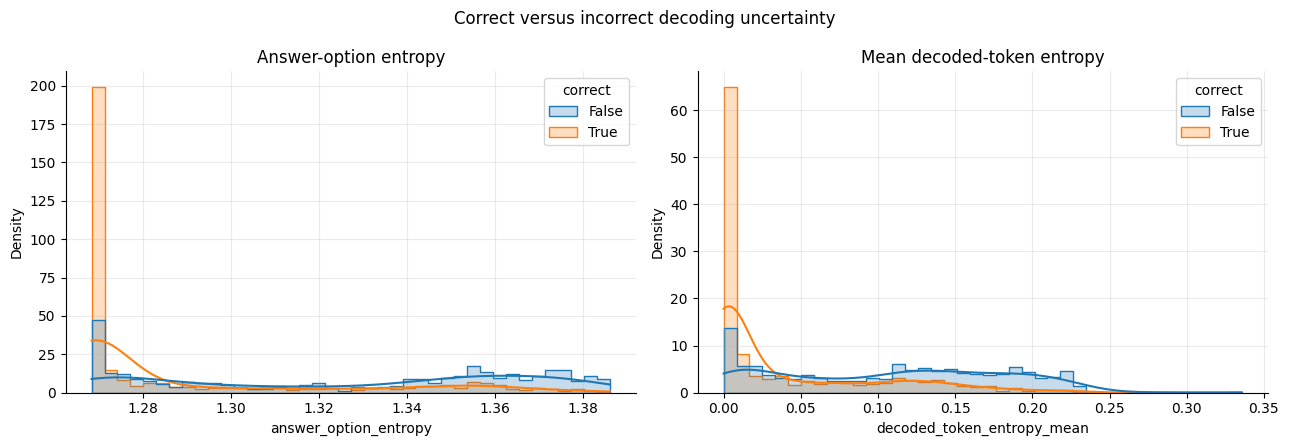

In [188]:
selected_entropy_run = entropy_df[entropy_df["run_id"] == SELECTED_RUN_ID].copy()
print(f"Selected entropy rows: {len(selected_entropy_run):,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (metric, title) in zip(axes, [
    ("answer_option_entropy", "Answer-option entropy"),
    ("decoded_token_entropy_mean", "Mean decoded-token entropy"),
]):
    usable = selected_entropy_run.dropna(subset=[metric])
    if HAS_SEABORN:
        sns.histplot(
            data=usable, x=metric, hue="correct", bins=40, kde=True,
            stat="density", common_norm=False, element="step", ax=ax,
        )
    else:
        for correct, group in usable.groupby("correct"):
            ax.hist(group[metric], bins=40, alpha=0.45, density=True, label=f"correct={correct}")
        ax.legend()
    ax.set_title(title)
plt.suptitle("Correct versus incorrect decoding uncertainty")
plt.tight_layout()
plt.show()


### Does Entropy or Attention Predict Errors?

AUC is the probability that a randomly selected incorrect example has a higher metric value than a randomly selected correct example. For attention mass, direction is empirical rather than assumed.


In [189]:
def error_detection_auc(frame, metric):
    usable = frame[[metric, "correct"]].dropna()
    if usable["correct"].nunique() < 2:
        return np.nan
    error = (~usable["correct"]).astype(int)
    n_error = int(error.sum())
    n_correct = int((1 - error).sum())
    ranks = usable[metric].rank(method="average")
    return float((ranks[error == 1].sum() - n_error * (n_error + 1) / 2) / (n_error * n_correct))


discrimination_rows = []
for run_id, group in entropy_df.groupby("run_id"):
    metadata = group.iloc[0]
    row = {
        **{key: metadata[key] for key in RUN_KEYS},
        "run_id": run_id,
        "samples": len(group),
        "accuracy": group["correct"].mean(),
    }
    for metric in [*ENTROPY_METRICS, *MASS_METRICS]:
        means = group.groupby("correct")[metric].mean()
        row[f"{metric}_error_gap"] = means.get(False, np.nan) - means.get(True, np.nan)
        row[f"{metric}_error_auc"] = error_detection_auc(group, metric)
    discrimination_rows.append(row)

error_discrimination = pd.DataFrame(discrimination_rows).sort_values(RUN_KEYS)
display(
    error_discrimination.style.format({
        "accuracy": "{:.2%}",
        **{
            column: "{:.5f}"
            for column in error_discrimination.columns
            if column.endswith("_gap") or column.endswith("_auc")
        },
    }).set_caption("Error separation from entropy and attention metrics")
)


,run_type,mined_by,context,evaluated_by,trace_variant,boost_target,layer_mode,alpha,run_id,samples,accuracy,answer_option_entropy_error_gap,answer_option_entropy_error_auc,decoded_token_entropy_mean_error_gap,decoded_token_entropy_mean_error_auc,decoded_token_entropy_median_error_gap,decoded_token_entropy_median_error_auc,decoded_token_entropy_max_error_gap,decoded_token_entropy_max_error_auc,trace_attention_mass_error_gap,trace_attention_mass_error_auc,visual_trace_attention_mass_error_gap,visual_trace_attention_mass_error_auc,think_attention_mass_error_gap,think_attention_mass_error_auc
0,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.010000,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.01,2318,63.98%,0.03503,0.78059,0.08728,0.76884,0.02636,0.53555,0.39002,0.76197,0.00442,0.57673,0.00026,0.50207,0.00416,0.57119
1,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.100000,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.1,2318,0.00%,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
2,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.200000,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.2,2318,0.09%,0.01680,0.83901,0.64602,0.68977,0.46796,0.61265,1.14720,0.86503,0.00539,0.56088,0.00045,0.51446,0.00494,0.59316
3,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.300000,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.3,2318,0.00%,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
4,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.400000,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.4,2318,0.04%,-0.00633,0.61300,-0.95030,0.21592,-0.94396,0.26785,1.83900,0.94245,-0.07390,0.02072,-0.10352,0.00432,0.02962,0.75939
5,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,all,0.500000,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | all | 0.5,2318,0.04%,-0.00336,0.66417,0.58995,0.68793,0.60873,0.66840,3.36642,0.98655,-0.07269,0.02460,-0.10747,0.00820,0.03478,0.75939
6,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,latter_half,0.010000,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | latter_half | 0.01,2318,65.88%,0.03676,0.78988,0.06709,0.78507,0.00002,0.47735,0.39714,0.78372,0.00073,0.53876,-0.00012,0.49764,0.00085,0.53253
7,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,latter_half,0.100000,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | latter_half | 0.1,2318,64.75%,0.03562,0.78724,0.06440,0.77866,0.00024,0.51488,0.37879,0.77716,0.00078,0.53365,-0.00019,0.49859,0.00097,0.52674
8,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,latter_half,0.200000,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | latter_half | 0.2,2318,63.98%,0.03493,0.78438,0.06456,0.77542,-0.00001,0.51161,0.37966,0.77452,0.00106,0.53593,-0.00026,0.49639,0.00131,0.52517
9,full_lvar,full_lvar,global,lvar+controller,controller_generated,trace_all,latter_half,0.300000,full_lvar | full_lvar | global | lvar+controller | controller_generated | trace_all | latter_half | 0.3,2318,63.68%,0.03364,0.77668,0.06329,0.76765,0.00028,0.50793,0.37345,0.76655,0.00156,0.53804,-0.00005,0.49943,0.00161,0.52493


### Accuracy Across Entropy Quantiles


,metric_quantile,samples,accuracy,mean_metric,metric,quantile_rank
0,"(1.26829, 1.26834]",457,96.50%,1.26831,answer_option_entropy,1
1,"(1.26834, 1.26983]",456,84.21%,1.26872,answer_option_entropy,2
2,"(1.26983, 1.29662]",456,62.28%,1.27898,answer_option_entropy,3
3,"(1.29662, 1.35154]",456,53.95%,1.32709,answer_option_entropy,4
4,"(1.35154, 1.3861]",456,32.89%,1.36639,answer_option_entropy,5
5,"(-0.0009763, 0.00115]",464,92.46%,0.00045,decoded_token_entropy_mean,1
6,"(0.00115, 0.00868]",463,87.69%,0.00357,decoded_token_entropy_mean,2
7,"(0.00868, 0.0635]",464,62.93%,0.02943,decoded_token_entropy_mean,3
8,"(0.0635, 0.136]",463,53.78%,0.10277,decoded_token_entropy_mean,4
9,"(0.136, 0.336]",464,32.54%,0.17802,decoded_token_entropy_mean,5


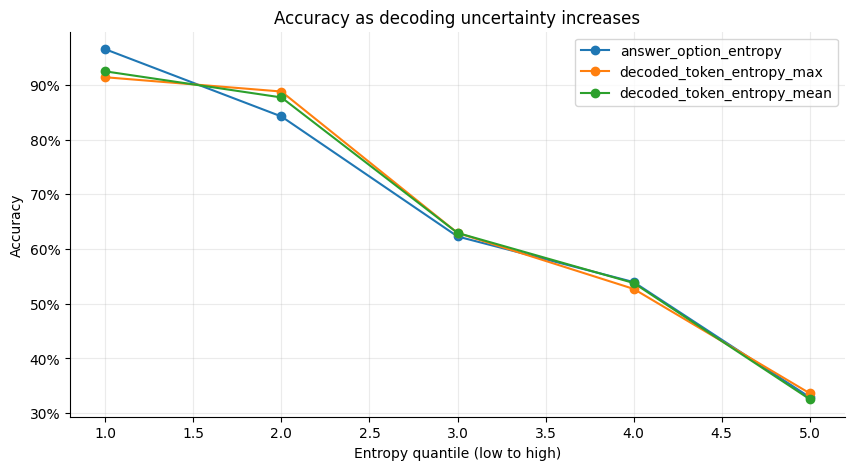

In [190]:
quantile_rows = []
for metric in ["answer_option_entropy", "decoded_token_entropy_mean", "decoded_token_entropy_max"]:
    usable = selected_entropy_run.dropna(subset=[metric]).copy()
    if usable[metric].nunique() < 2:
        continue
    usable["metric_quantile"] = pd.qcut(
        usable[metric], q=min(5, usable[metric].nunique()), duplicates="drop"
    )
    grouped = usable.groupby("metric_quantile", observed=True).agg(
        samples=("example_id", "size"),
        accuracy=("correct", "mean"),
        mean_metric=(metric, "mean"),
    ).reset_index()
    grouped["metric"] = metric
    grouped["quantile_rank"] = range(1, len(grouped) + 1)
    grouped["metric_quantile"] = grouped["metric_quantile"].astype(str)
    quantile_rows.append(grouped)

entropy_quantiles = pd.concat(quantile_rows, ignore_index=True) if quantile_rows else pd.DataFrame()
display(entropy_quantiles.style.format({"accuracy": "{:.2%}", "mean_metric": "{:.5f}"}))

if not entropy_quantiles.empty:
    for metric, group in entropy_quantiles.groupby("metric"):
        plt.plot(group["quantile_rank"], group["accuracy"], marker="o", label=metric)
    plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
    plt.xlabel("Entropy quantile (low to high)")
    plt.ylabel("Accuracy")
    plt.title("Accuracy as decoding uncertainty increases")
    plt.legend()
    plt.show()


### Entropy, Attention, and Confidence Relationships


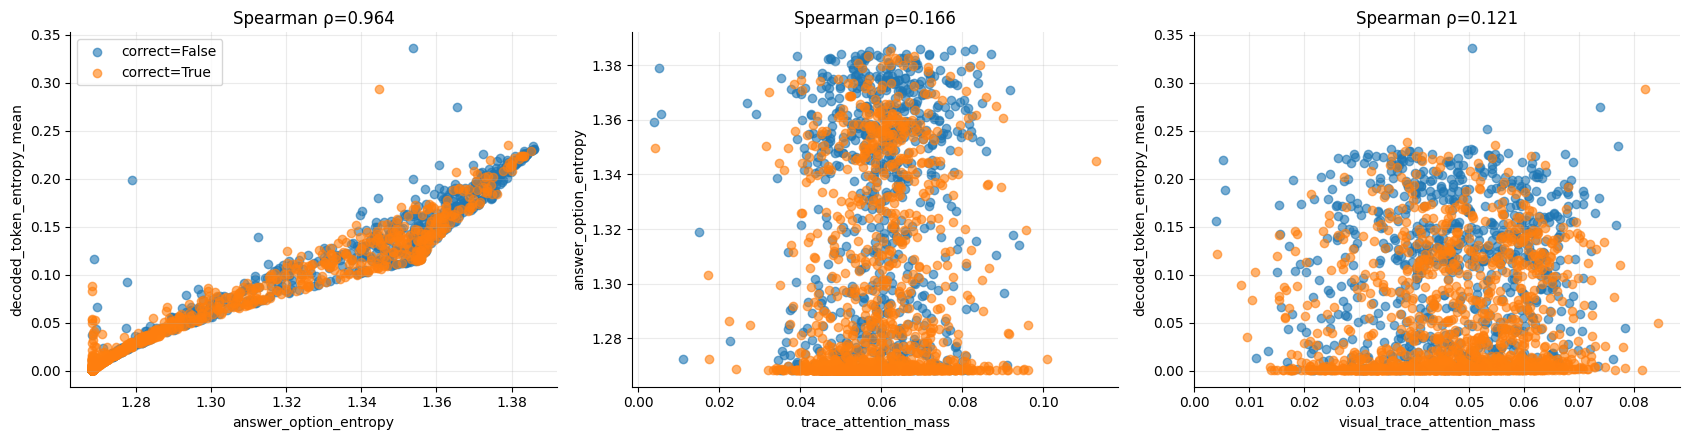

In [191]:
scatter_metrics = [
    ("answer_option_entropy", "decoded_token_entropy_mean"),
    ("trace_attention_mass", "answer_option_entropy"),
    ("visual_trace_attention_mass", "decoded_token_entropy_mean"),
]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (x_metric, y_metric) in zip(axes, scatter_metrics):
    usable = selected_entropy_run.dropna(subset=[x_metric, y_metric])
    correlation = usable[[x_metric, y_metric]].corr(method="spearman").iloc[0, 1] if len(usable) >= 2 else np.nan
    for correct, group in usable.groupby("correct"):
        ax.scatter(group[x_metric], group[y_metric], alpha=0.6, label=f"correct={correct}")
    ax.set_xlabel(x_metric)
    ax.set_ylabel(y_metric)
    ax.set_title(f"Spearman ρ={correlation:.3f}")
axes[0].legend()
plt.tight_layout()
plt.show()


## 7. Error and Success Examples

These tables surface inference examples with unusually high or low trace attention, confident errors, and uncertain successes. They intentionally avoid mining-time trace features.


In [192]:
def compact_question(text):
    if not isinstance(text, str):
        return text
    text = re.sub(r"\s+", " ", text).strip()
    return text[:260] + ("..." if len(text) > 260 else "")


inspection = selected_predictions.copy()
inspection["question"] = inspection["question"].map(compact_question)
inspection_cols = [
    "example_id", "domain", "topic", "gold_answer", "decoded_answer",
    "generated_text", "trace_attention_mass", "visual_trace_attention_mass",
    "think_attention_mass", "num_inference_trace_actions", "num_output_tokens", "question",
]

print("Incorrect examples with highest trace attention")
display(inspection[~inspection["correct"]].sort_values("trace_attention_mass", ascending=False)[inspection_cols].head(15))

print("Correct examples with lowest trace attention")
display(inspection[inspection["correct"]].sort_values("trace_attention_mass", ascending=True)[inspection_cols].head(15))

if not selected_entropy_run.empty:
    entropy_inspection = selected_entropy_run.merge(
        selected_predictions[["example_id", "question", "domain", "topic", "generated_text"]],
        on="example_id", how="left",
    )
    print("Most confident errors by answer-option entropy")
    display(
        entropy_inspection[~entropy_inspection["correct"]]
        .sort_values("answer_option_entropy", ascending=True)
        [[
            "example_id", "domain", "topic", "gold_answer", "decoded_answer",
            "answer_option_entropy", "decoded_token_entropy_mean",
            "trace_attention_mass", "generated_text", "question",
        ]]
        .head(15)
    )


Incorrect examples with highest trace attention


,example_id,domain,topic,gold_answer,decoded_answer,generated_text,trace_attention_mass,visual_trace_attention_mass,think_attention_mass,num_inference_trace_actions,num_output_tokens,question
28496,mathematics-547,mathematics,theory,b,None,"Therefore, the answer is A",0.094093,0.070730,0.023363,9,6,[Question]:{Which option is the correct answer for this Number Theory problem in the picture?} [Options]: (A).{It seems like there's an error in all the pro...
28364,mathematics-200,mathematics,algebra,c,None,"Therefore, the answer is B",0.092501,0.065169,0.027332,9,6,"[Question]:{After thoroughly reviewing the picture, can you confidently pick the right option that solves the Counting & Probability problem?} [Options]: (A..."
29766,economics-647,science,social-science,c,None,"Therefore, the answer is A",0.091880,0.070789,0.021091,8,6,"[Question]:{Can you provide the average hourly wages figures for Country 3 and Country 5 in 2020?} [Options]: (A).{81.64 ($/h), 47.82 ($/h)} (B).{47.82 ($/h..."
29607,cognitive-science-105,science,social-science,b,None,"Therefore, the answer is C",0.091092,0.066379,0.024713,8,6,[Question]:{What does the tangram image represent?} [Options]: (A).{a kneeling person} (B).{a person waving} (C).{a person doing a high jumping} (D).{a pers...
28285,mathematics-55,mathematics,algebra,a,None,"Therefore, the answer is B",0.090167,0.062868,0.027299,9,6,"[Question]:{After reviewing the following questions, can you determine if option C in the image is the correct choice?} [Options]: (A).{False} (B).{True} (C..."
28453,mathematics-278,mathematics,geometry,a,None,"Therefore, the answer is B",0.088427,0.062264,0.026163,8,6,[Question]:{I'm not sure about the correct option for the Geometry problem. Can you assist me?} [Options]: (A).{the solution is option D in the image.} (B)....
29633,economics-169,science,social-science,c,None,"Therefore, the answer is A",0.087089,0.067426,0.019664,8,6,"[Question]:{Can you provide the balances of trade figures for Country 4 and Country 5 in 2020?} [Options]: (A).{-0.64 x 10^12 $, -0.41 x 10^12 $} (B).{-0.64..."
28336,mathematics-32,mathematics,algebra,d,None,"Therefore, the answer is B",0.085947,0.058121,0.027827,8,6,[Question]:{The following picture is a test of a Algebra problem. Which of the following options is correct?} [Options]: (A).{option C in the image is the a...
28282,mathematics-27,mathematics,algebra,c,None,"Therefore, the answer is B",0.084935,0.060772,0.024163,9,6,[Question]:{I'm not sure about the correct option for the Algebra problem. Can you assist me?} [Options]: (A).{the answer is option A in the image.} (B).{th...
29851,economics-1096,science,social-science,c,None,"Therefore, the answer is A",0.084364,0.060191,0.024174,9,6,[Question]:{What is the country with the highest GDP per capita in 2018 among those in Country 4 and Country 3?} [Options]: (A).{Country 4 exhibits a higher...


Correct examples with lowest trace attention


,example_id,domain,topic,gold_answer,decoded_answer,generated_text,trace_attention_mass,visual_trace_attention_mass,think_attention_mass,num_inference_trace_actions,num_output_tokens,question
29328,physical-commonsense-45,science,natural-science,b,None,"Therefore, the answer is B",0.004196,0.004196,0.000000,2,6,[Question]:{Can you determine the number of objects in the image's options that will descend beneath the water's surface?} [Options]: (A).{1} (B).{0} (C).{2...
27954,social-commonsense-1308,commonsense,social-commonsense,b,None,"Therefore, the answer is B",0.017282,0.017282,0.000000,8,6,[Question]:{What is likely happening in the scene?} [Options]: (A).{A snowboarding lesson is taking place} (B).{A snowboarding competition is happening} (C)...
28015,social-commonsense-1632,commonsense,social-commonsense,c,None,"Therefore, the answer is C",0.017562,0.017562,0.000000,8,6,[Question]:{What is the likely use of the room shown in the picture?} [Options]: (A).{Home gym} (B).{Artist Studio} (C).{Music room} (D).{Study room} Answer:
28260,mathematics-1493,commonsense,temporal-commonsense,a,None,"Therefore, the answer is A",0.022287,0.022287,0.000000,6,6,"[Question]:{Look at the following schedule. Cora is at Kite Coast. If she wants to arrive at Ocean City at 10.30 AM, what time should she get on the boat?} ..."
29083,physics-637,science,natural-science,c,None,"Therefore, the answer is C",0.024234,0.024234,0.000000,6,6,[Question]:{Compare the average kinetic energies of the particles in each sample. Which sample has the higher temperature?} [Options]: (A).{neither; the sam...
28146,synthesis-problem-8,commonsense,social-commonsense,d,None,"Therefore, the answer is D",0.027581,0.009591,0.017990,4,6,[Question]:{What can be inferred from the image?} [Options]: (A).{There was a child playing with a boat here} (B).{It is high tide currently} (C).{The skate...
29417,physical-commonsense-1185,science,natural-science,a,None,"Therefore, the answer is A",0.031623,0.015468,0.016154,5,6,"[Question]:{Among the options provided in the image, which object will exhibit water droplets first when left at room temperature?} [Options]: (A).{As every..."
29128,physics-1414,science,natural-science,a,None,"Therefore, the answer is A",0.032151,0.014569,0.017582,6,6,[Question]:{Think about the magnetic force between the magnets in each pair. Which of the following statements is true?} [Options]: (A).{The magnitude of th...
28389,mathematics-1384,mathematics,algebra,c,None,"Therefore, the answer is C",0.032237,0.032237,0.000000,6,6,[Question]:{I find Precalculus problem challenging. Can you verify if my answer is right?} [Options]: (A).{the correct choice is option C in the image.} (B)...
29061,physics-713,science,natural-science,c,None,"Therefore, the answer is C",0.033307,0.014977,0.018330,6,6,[Question]:{Compare the average kinetic energies of the particles in each sample. Which sample has the higher temperature?} [Options]: (A).{sample A} (B).{n...


Most confident errors by answer-option entropy


,example_id,domain,topic,gold_answer,decoded_answer,answer_option_entropy,decoded_token_entropy_mean,trace_attention_mass,generated_text,question
19,physical-commonsense-1399,commonsense,physical-commonsense,b,"Therefore, the answer is C",1.268303,0.000177,0.048868,"Therefore, the answer is C",[Question]:{What can you infer about the current weather conditions?}\n[Options]:\n(A).{It is cloudy and overcast}\n(B).{It is warm and sunny}\n(C).{It is c...
155,social-commonsense-1242,commonsense,social-commonsense,d,"Therefore, the answer is C",1.268304,0.000121,0.076870,"Therefore, the answer is C",[Question]:{What can you infer about the person boarding the bus?}\n[Options]:\n(A).{They are a tourist or student}\n(B).{They have a disability}\n(C).{All ...
1051,biology-836,science,natural-science,a,"Therefore, the answer is B",1.268305,0.000611,0.045620,"Therefore, the answer is B",[Question]:{Examine the image and then state the scientific name of the organism shown.}\n[Options]:\n(A).{Corallus hortulanus}\n(B).{Python bivittatus}\n(C...
262,social-commonsense-1559,commonsense,social-commonsense,a,"Therefore, the answer is C",1.268307,0.000145,0.061770,"Therefore, the answer is C",[Question]:{What can be inferred about the town shown in the image?}\n[Options]:\n(A).{There is a special event happening}\n(B).{The weather is sunny and dr...
1789,cognitive-science-3,science,social-science,c,"Therefore, the answer is B",1.268308,0.000350,0.046149,"Therefore, the answer is B",[Question]:{What animal can you see in the image?}\n[Options]:\n(A).{Car}\n(B).{Rat}\n(C).{Dog}\n(D).{Train}\nAnswer:\n
289,synthesis-problem-202,commonsense,social-commonsense,b,"Therefore, the answer is D",1.268310,0.001865,0.037913,"Therefore, the answer is D",[Question]:{What can you infer about the girl from the image?}\n[Options]:\n(A).{She is an experienced skier}\n(B).{She is wearing the wrong size helmet}\n(...
179,social-commonsense-435,commonsense,social-commonsense,a,"Therefore, the answer is D",1.268311,0.000172,0.059526,"Therefore, the answer is D",[Question]:{What can you infer about the location based on the image?}\n[Options]:\n(A).{It is a Spanish-speaking country}\n(B).{It is a French-speaking cou...
15,physical-commonsense-1436,commonsense,physical-commonsense,b,"Therefore, the answer is C",1.268311,0.000209,0.045297,"Therefore, the answer is C",[Question]:{Why does the front of the train appear dirty?}\n[Options]:\n(A).{The train was caught in a rainstorm}\n(B).{The train has not been washed in som...
1151,biology-1180,science,natural-science,c,"Therefore, the answer is A",1.268314,0.000674,0.049759,"Therefore, the answer is A",[Question]:{Examine the image and then state the scientific name of the organism shown.}\n[Options]:\n(A).{Lissotriton helveticus}\n(B).{Taricha torosa}\n(C...
1030,biology-1592,science,natural-science,b,"Therefore, the answer is A",1.268316,0.010199,0.056929,"Therefore, the answer is A",[Question]:{Select the bird below.}\n[Options]:\n(A).{Figure 1}\n(B).{Figure 2}\nAnswer:\n


## 8. Domain and Topic Breakdown

Accuracy and attention mass are summarized across M3CoT domains and topics for every boost configuration.


In [193]:
domain_summary = (
    predictions.dropna(subset=["domain"])
    .groupby(RUN_KEYS + ["domain"], dropna=False)
    .agg(
        examples=("example_id", "nunique"),
        accuracy=("correct", "mean"),
        mean_trace_attention_mass=("trace_attention_mass", "mean"),
        mean_visual_trace_attention_mass=("visual_trace_attention_mass", "mean"),
        mean_think_attention_mass=("think_attention_mass", "mean"),
    )
    .reset_index()
)
domain_summary["accuracy_pct"] = 100 * domain_summary["accuracy"]
display(
    domain_summary.sort_values(["accuracy", "examples"], ascending=[False, False]).head(60)
    .style.format({
        "alpha": "{:.1f}", "accuracy": "{:.4f}", "accuracy_pct": "{:.2f}",
        "mean_trace_attention_mass": "{:.5f}",
        "mean_visual_trace_attention_mass": "{:.5f}",
        "mean_think_attention_mass": "{:.5f}",
    })
)


,run_type,mined_by,context,evaluated_by,trace_variant,boost_target,layer_mode,alpha,domain,examples,accuracy,mean_trace_attention_mass,mean_visual_trace_attention_mass,mean_think_attention_mass,accuracy_pct
93,oracle,ivtlr,global,ivtlr,raw,trace_all,latter_half,0.1,commonsense,455,0.7868,0.05741,0.04492,0.01249,78.68
129,oracle,ivtlr,global,ivtlr,raw,trace_visual,latter_half,0.1,commonsense,455,0.7868,0.05487,0.04657,0.00830,78.68
108,oracle,ivtlr,global,ivtlr,raw,trace_visual,all,0.0,commonsense,455,0.7802,0.04910,0.03474,0.01437,78.02
90,oracle,ivtlr,global,ivtlr,raw,trace_all,latter_half,0.0,commonsense,455,0.7780,0.03374,0.02463,0.00911,77.80
96,oracle,ivtlr,global,ivtlr,raw,trace_all,latter_half,0.2,commonsense,455,0.7780,0.08130,0.06425,0.01705,77.80
126,oracle,ivtlr,global,ivtlr,raw,trace_visual,latter_half,0.0,commonsense,455,0.7780,0.03349,0.02469,0.00880,77.80
132,oracle,ivtlr,global,ivtlr,raw,trace_visual,latter_half,0.2,commonsense,455,0.7758,0.07625,0.06823,0.00802,77.58
162,oracle,lvar,global,lvar,raw,trace_all,latter_half,0.0,commonsense,455,0.7758,0.03352,0.02737,0.00615,77.58
198,oracle,lvar,global,lvar,raw,trace_visual,latter_half,0.0,commonsense,455,0.7758,0.03334,0.02740,0.00594,77.58
201,oracle,lvar,global,lvar,raw,trace_visual,latter_half,0.1,commonsense,455,0.7714,0.05498,0.04948,0.00550,77.14


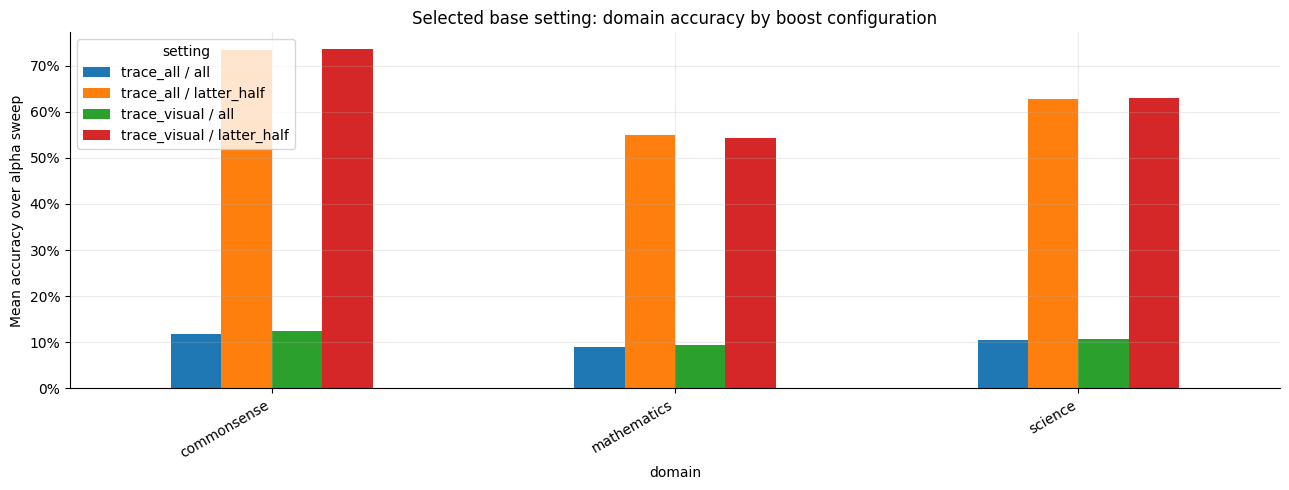

,run_type,mined_by,context,evaluated_by,trace_variant,boost_target,layer_mode,alpha,topic,examples,accuracy,mean_trace_attention_mass,mean_visual_trace_attention_mass,mean_think_attention_mass,accuracy_pct
301,oracle,ivtlr,global,ivtlr,raw,trace_all,latter_half,0.30,physical-commonsense,90,0.833333,0.115792,0.096547,0.019245,83.333333
409,oracle,ivtlr,global,ivtlr,raw,trace_visual,latter_half,0.30,physical-commonsense,90,0.833333,0.109757,0.102596,0.007161,83.333333
497,oracle,lvar,global,lvar,raw,trace_all,latter_half,0.10,language-science,211,0.829384,0.068564,0.061010,0.007555,82.938389
605,oracle,lvar,global,lvar,raw,trace_visual,latter_half,0.10,language-science,211,0.829384,0.066846,0.061916,0.004931,82.938389
489,oracle,lvar,global,lvar,raw,trace_all,latter_half,0.01,natural-science,783,0.823755,0.040455,0.034817,0.005638,82.375479
597,oracle,lvar,global,lvar,raw,trace_visual,latter_half,0.01,natural-science,783,0.823755,0.040235,0.034849,0.005386,82.375479
283,oracle,ivtlr,global,ivtlr,raw,trace_all,latter_half,0.10,physical-commonsense,90,0.822222,0.068290,0.056424,0.011866,82.222222
292,oracle,ivtlr,global,ivtlr,raw,trace_all,latter_half,0.20,physical-commonsense,90,0.822222,0.094197,0.078450,0.015747,82.222222
310,oracle,ivtlr,global,ivtlr,raw,trace_all,latter_half,0.40,physical-commonsense,90,0.822222,0.138220,0.115553,0.022666,82.222222
391,oracle,ivtlr,global,ivtlr,raw,trace_visual,latter_half,0.10,physical-commonsense,90,0.822222,0.066050,0.058117,0.007933,82.222222


In [194]:
topic_summary = (
    predictions.dropna(subset=["topic"])
    .groupby(RUN_KEYS + ["topic"], dropna=False)
    .agg(
        examples=("example_id", "nunique"),
        accuracy=("correct", "mean"),
        mean_trace_attention_mass=("trace_attention_mass", "mean"),
        mean_visual_trace_attention_mass=("visual_trace_attention_mass", "mean"),
        mean_think_attention_mass=("think_attention_mass", "mean"),
    )
    .reset_index()
)
topic_summary["accuracy_pct"] = 100 * topic_summary["accuracy"]

selected_domain = domain_summary[
    (domain_summary["run_type"] == selected_summary.iloc[0]["run_type"])
    & (domain_summary["mined_by"] == selected_summary.iloc[0]["mined_by"])
    & (domain_summary["context"] == selected_summary.iloc[0]["context"])
    & (domain_summary["evaluated_by"] == selected_summary.iloc[0]["evaluated_by"])
    & (domain_summary["trace_variant"] == selected_summary.iloc[0]["trace_variant"])
]
if not selected_domain.empty:
    chart = (
        selected_domain.groupby(["domain", "boost_target", "layer_mode"], dropna=False)
        .agg(accuracy=("accuracy", "mean"))
        .reset_index()
    )
    chart["setting"] = chart["boost_target"] + " / " + chart["layer_mode"]
    pivot = chart.pivot(index="domain", columns="setting", values="accuracy")
    pivot.plot(kind="bar", figsize=(13, 5))
    plt.gca().yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
    plt.ylabel("Mean accuracy over alpha sweep")
    plt.title("Selected base setting: domain accuracy by boost configuration")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

display(topic_summary.sort_values(["accuracy", "examples"], ascending=[False, False]).head(60))


## 9. Export Analysis Tables

Set `EXPORT_TABLES = True` to save inference-only tables for reporting or further analysis.


In [195]:
EXPORT_TABLES = False
EXPORT_DIR = ROOT / "analysis/test_trace_answer_boosted_analysis_tables"

if EXPORT_TABLES:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    run_summary.to_csv(EXPORT_DIR / "boosted_run_summary.csv", index=False)
    sweep_coverage.to_csv(EXPORT_DIR / "sweep_coverage.csv", index=False)
    ranked_runs.to_csv(EXPORT_DIR / "ranked_runs.csv", index=False)
    best_per_base.to_csv(EXPORT_DIR / "best_setting_per_base.csv", index=False)
    predictions.to_csv(EXPORT_DIR / "predictions_by_sample.csv", index=False)
    correctness_summary.to_csv(EXPORT_DIR / "correctness_summary.csv", index=False)
    alpha_response.to_csv(EXPORT_DIR / "alpha_response.csv", index=False)
    entropy_df.drop(
        columns=["answer_option_probabilities", "decoded_token_entropies"], errors="ignore"
    ).to_csv(EXPORT_DIR / "entropy_by_sample.csv", index=False)
    entropy_summary.to_csv(EXPORT_DIR / "entropy_summary.csv", index=False)
    error_discrimination.to_csv(EXPORT_DIR / "error_discrimination.csv", index=False)
    domain_summary.to_csv(EXPORT_DIR / "domain_summary.csv", index=False)
    topic_summary.to_csv(EXPORT_DIR / "topic_summary.csv", index=False)
    print(f"Wrote analysis tables to {EXPORT_DIR}")
else:
    print("Set EXPORT_TABLES = True to write CSV outputs.")


Set EXPORT_TABLES = True to write CSV outputs.
